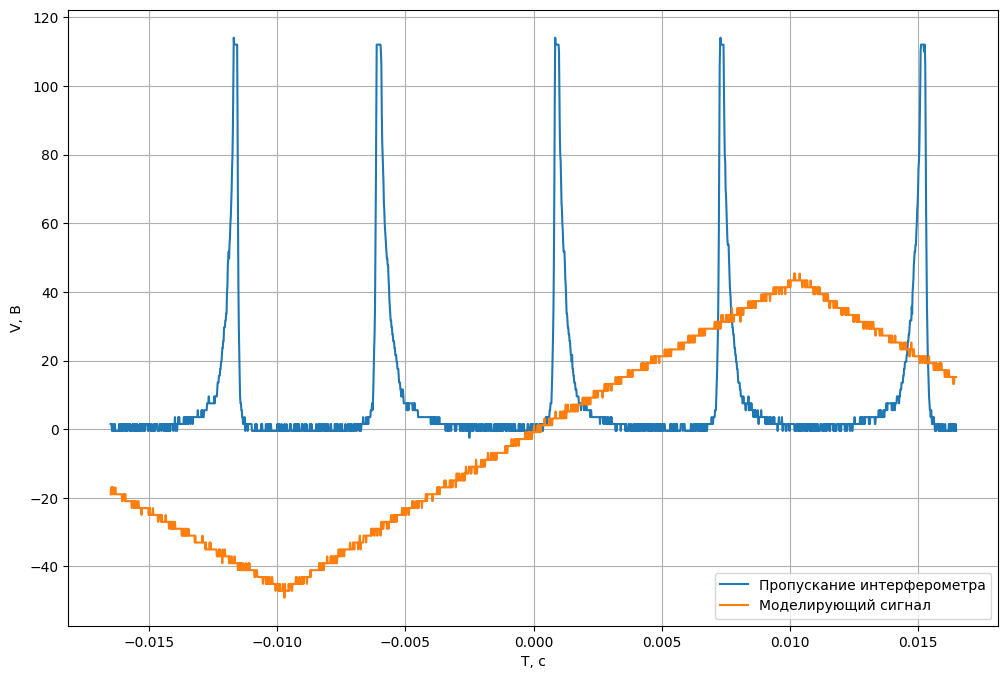

Fitted centers (time): [-0.00596218  0.00097708  0.0073997 ]


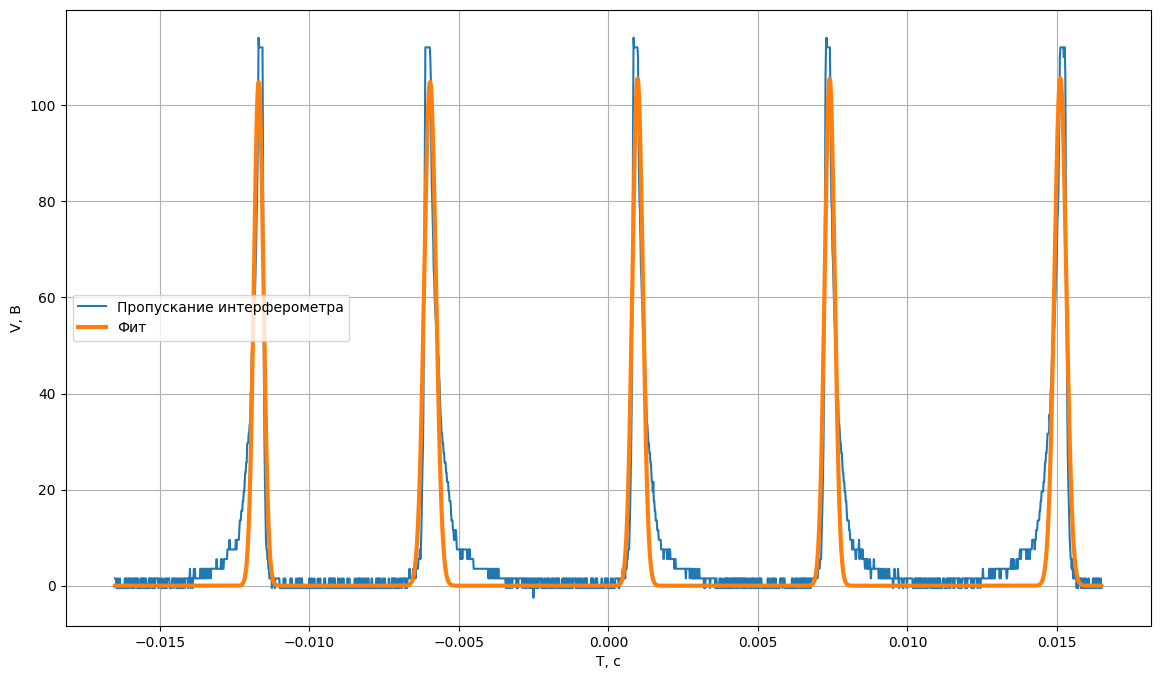

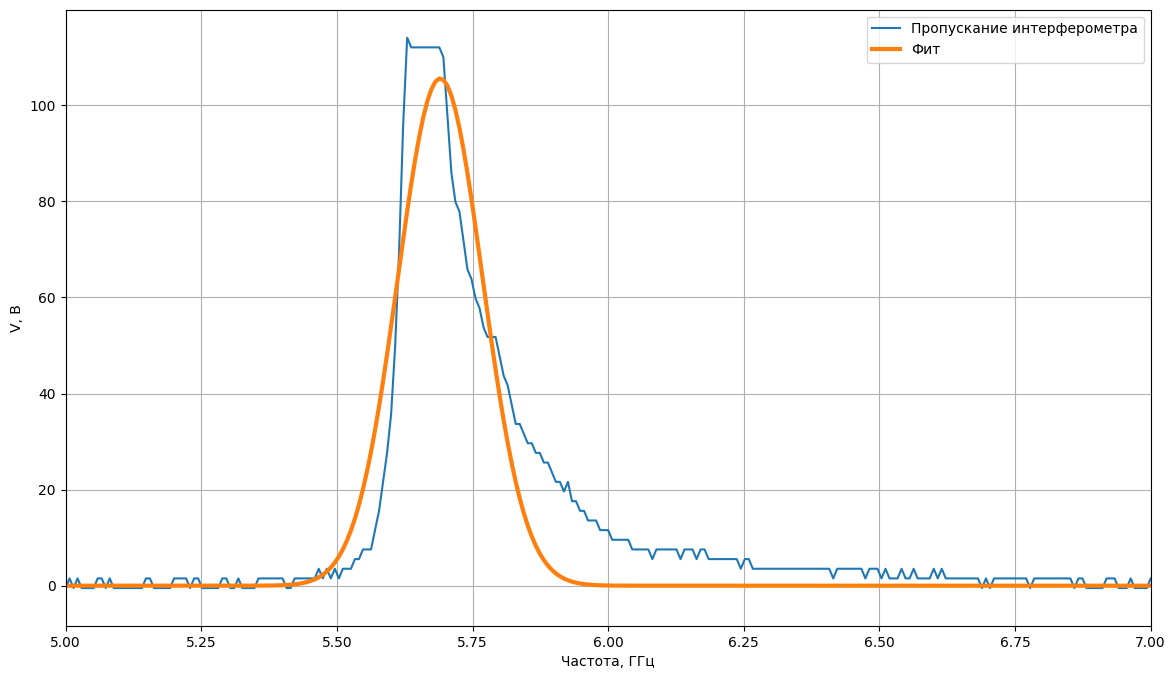


Ширины пиков:

Пик 1
sigma  = 0.07216 GHz
FWHM   = 0.16993 GHz

Пик 2
sigma  = 0.08850 GHz
FWHM   = 0.20840 GHz

Пик 3
sigma  = 0.07814 GHz
FWHM   = 0.18402 GHz

Пик 4
sigma  = 0.07568 GHz
FWHM   = 0.17821 GHz

Пик 5
sigma  = 0.08910 GHz
FWHM   = 0.20982 GHz



In [104]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from scipy.signal import find_peaks
from scipy.optimize import curve_fit


# ============================================================
#                     ЗАГРУЗКА ДАННЫХ
# ============================================================

data_0 = pd.read_csv("scope_0.csv")
data_1 = pd.read_csv("scope_1.csv")
data_2 = pd.read_csv("scope_2.csv")
data_3 = pd.read_csv("scope_3.csv")



# ============================================================
#                     БАЗОВЫЕ ФУНКЦИИ
# ============================================================

def plot_raw_data(data):
    """
    Исходные сигналы
    """

    plt.figure(figsize=(12, 8))

    plt.plot(data["T"], data["V1"], label="Пропускание интерферометра")
    plt.plot(data["T"], data["V2"], label="Моделирующий сигнал")

    plt.grid()
    plt.xlabel("T, c")
    plt.ylabel("V, В")
    plt.legend()
    plt.savefig("raw_data.png", dpi=300)

    plt.show()


def gaussian(x, A, x0, sigma):
    """
    Одна гауссиана
    """

    return A * np.exp(-(x - x0)**2 / (2 * sigma**2))


def multi_gaussian(x, *params):
    """
    Сумма гауссиан

    params:
    [A1, x01, sigma1, A2, x02, sigma2, ...]
    """

    result = np.zeros_like(x)

    for i in range(0, len(params), 3):

        A = params[i]
        x0 = params[i + 1]
        sigma = params[i + 2]

        result += gaussian(x, A, x0, sigma)

    return result


# ============================================================
#                 ПОИСК НАЧАЛЬНЫХ ПИКОВ
# ============================================================

def find_peak_positions(x, y, n_peaks=5,
                        prominence=10,
                        distance=50):
    """
    Ищет n_peaks самых высоких пиков
    """

    peaks, props = find_peaks(
        y,
        prominence=prominence,
        distance=distance
    )

    # берём самые высокие
    top_peaks = peaks[np.argsort(y[peaks])[-n_peaks:]]

    # сортируем по координате
    top_peaks = top_peaks[np.argsort(x[top_peaks])]

    return top_peaks


# ============================================================
#                     ОСНОВНОЙ ФИТ
# ============================================================

def fit_gaussians(x, y,
                  n_peaks=5,
                  initial_amplitude=120,
                  initial_sigma=0.001):
    """
    Фитирует данные суммой гауссиан
    """

    peaks = find_peak_positions(x, y, n_peaks=n_peaks)

    p0 = []

    for peak in peaks:

        A0 = initial_amplitude
        x0 = x[peak]
        sigma0 = initial_sigma

        p0.extend([A0, x0, sigma0])

    popt, pcov = curve_fit(
        multi_gaussian,
        x,
        y,
        p0=p0,
        maxfev=100000
    )

    return popt, pcov, peaks


# ============================================================
#                 ШИРИНА ПИКА В ГГц
# ============================================================

def find_width(data,
               peak_spacing_GHz=3,
               n_peaks=5):
    """
    Фитирует пики и переводит ширину в ГГц

    Между соседними пиками:
        peak_spacing_GHz

    Возвращает:
        widths_GHz
    """

    x = data["T"].values
    y = data["V1"].values

    popt, pcov, peaks = fit_gaussians(
        x,
        y,
        n_peaks=n_peaks
    )

    # ----------------------------------------
    # калибровка времени в частоту
    # ----------------------------------------

    fitted_centers = []

    for i in range(n_peaks):
        fitted_centers.append(popt[3*i + 1])


    fitted_centers = np.array(fitted_centers[1:4])
    print("Fitted centers (time):", fitted_centers)
    peak_distances = np.diff(fitted_centers)

    mean_distance_time = np.mean(peak_distances)

    GHz_per_second = peak_spacing_GHz / mean_distance_time

    # ----------------------------------------
    # ширины
    # ----------------------------------------

    sigmas_time = []
    sigmas_GHz = []

    FWHM_GHz = []

    for i in range(n_peaks):

        sigma_time = popt[3*i + 2]

        sigma_freq = sigma_time * GHz_per_second

        # FWHM = 2*sqrt(2ln2)*sigma
        fwhm = 2 * np.sqrt(2 * np.log(2)) * sigma_freq

        sigmas_time.append(sigma_time)
        sigmas_GHz.append(sigma_freq)
        FWHM_GHz.append(fwhm)

    return {
        "popt": popt,
        "peaks": peaks,
        "GHz_per_second": GHz_per_second,
        "sigmas_GHz": np.array(sigmas_GHz),
        "FWHM_GHz": np.array(FWHM_GHz)
    }


# ============================================================
#               ГРАФИК ВО ВРЕМЕННОЙ ШКАЛЕ
# ============================================================

def plot_fit_time_domain(data, fit_result):

    x = data["T"].values
    y = data["V1"].values

    popt = fit_result["popt"]

    y_fit = multi_gaussian(x, *popt)

    plt.figure(figsize=(14, 8))

    plt.plot(x, y, label="Пропускание интерферометра")
    plt.plot(x, y_fit, linewidth=3, label="Фит")


    n_peaks = len(popt) // 3

    for i in range(n_peaks):

        A = popt[3*i]
        x0 = popt[3*i + 1]
        sigma = popt[3*i + 2]

        # plt.plot(
        #     x,
        #     gaussian(x, A, x0, sigma),
        #     "--",
        #     label=f"Peak {i+1}"
        # )

    plt.grid()
    plt.xlabel("T, c")
    plt.ylabel("V, В")
    plt.legend()

    plt.show()


# ============================================================
#               ГРАФИК В ЧАСТОТНОЙ ШКАЛЕ
# ============================================================

def plot_frequency_domain(data, fit_result):
    """
    График в частотной шкале с обрезкой по оси x
    """
    
    # Определяем пределы обрезки (примерно ±8 ГГц от центра)
    x_min, x_max = 5, 7
    x = data["T"].values
    y = data["V1"].values

    popt = fit_result["popt"]

    GHz_per_second = fit_result["GHz_per_second"]

    # перевод времени в частоту
    # ноль ставим в первый пик

    first_center = popt[1]

    frequency_axis = (x - first_center) * GHz_per_second

    y_fit = multi_gaussian(x, *popt)

    plt.figure(figsize=(14, 8))
    plt.xlim(x_min, x_max)

    plt.plot(frequency_axis, y,  label="Пропускание интерферометра")
    plt.plot(frequency_axis, y_fit, 
             linewidth=3,
             label="Фит")

    plt.grid()

    plt.xlabel("Частота, ГГц")
    plt.ylabel("V, В")

    plt.legend()

    plt.show()


# ============================================================
#                     ПЕЧАТЬ ПАРАМЕТРОВ
# ============================================================

def print_peak_widths(fit_result):

    sigmas = fit_result["sigmas_GHz"]
    fwhm = fit_result["FWHM_GHz"]

    print("\nШирины пиков:\n")

    for i in range(len(sigmas)):

        print(f"Пик {i+1}")
        print(f"sigma  = {sigmas[i]:.5f} GHz")
        print(f"FWHM   = {fwhm[i]:.5f} GHz")
        print()


# ============================================================
#                        ЗАПУСК
# ============================================================

plot_raw_data(data_0)

fit_result = find_width(
    data_0,
    peak_spacing_GHz=3,
    n_peaks=5
)

plot_fit_time_domain(data_0, fit_result)

plot_frequency_domain(data_0, fit_result)

print_peak_widths(fit_result)

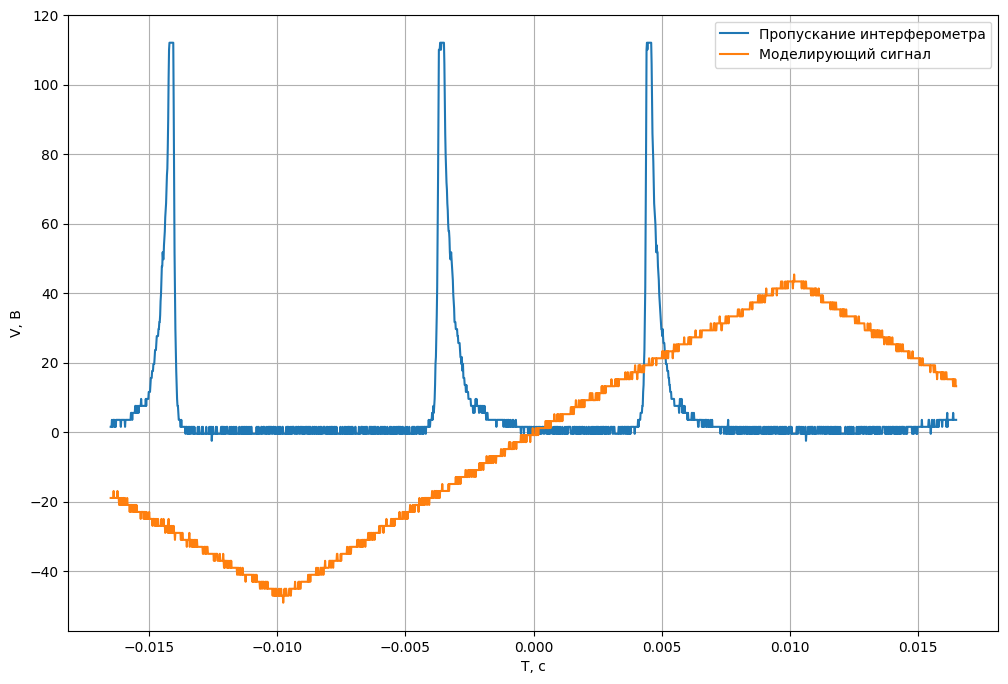

In [109]:
plot_raw_data(data_1)

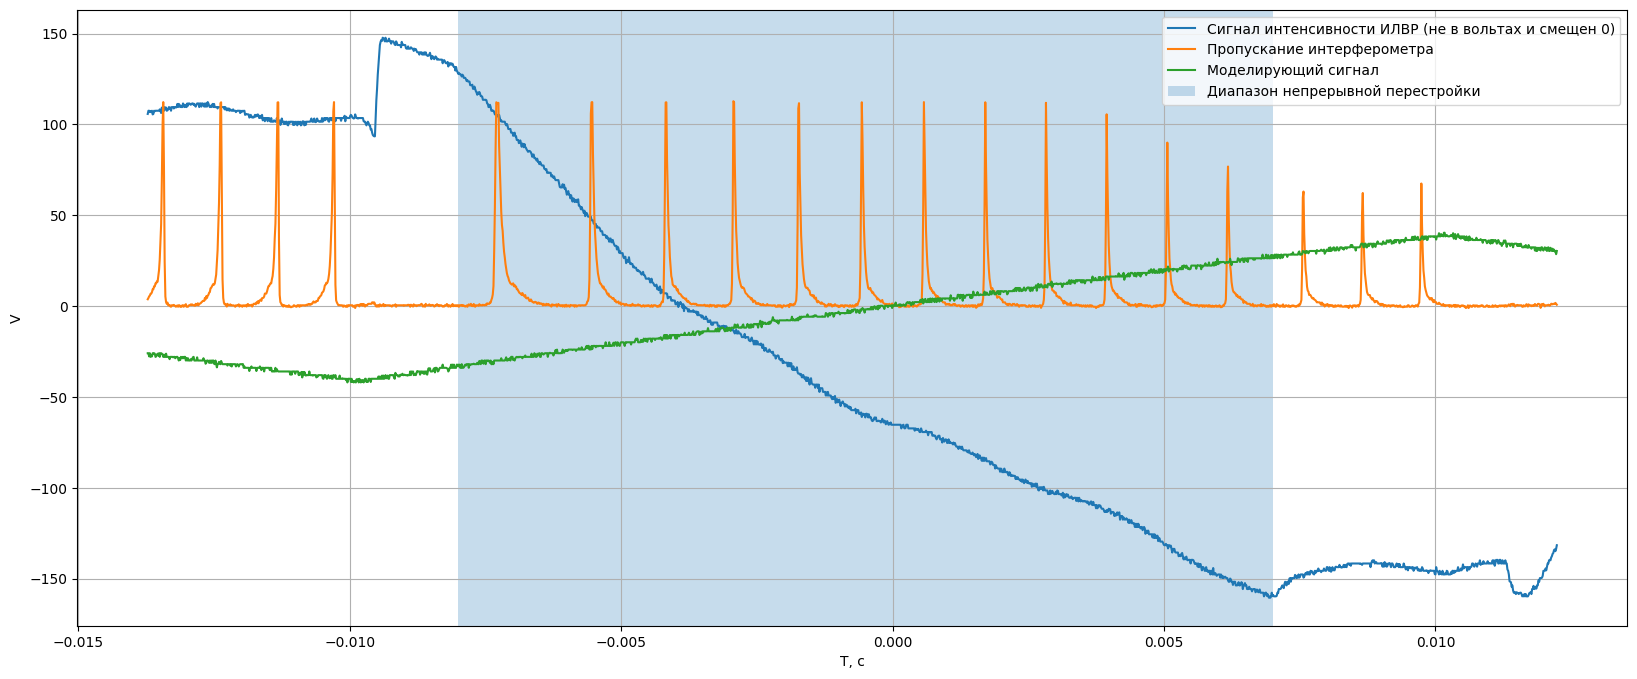

Количество пиков: 12

Калибровка:
2.448e+03 GHz / s


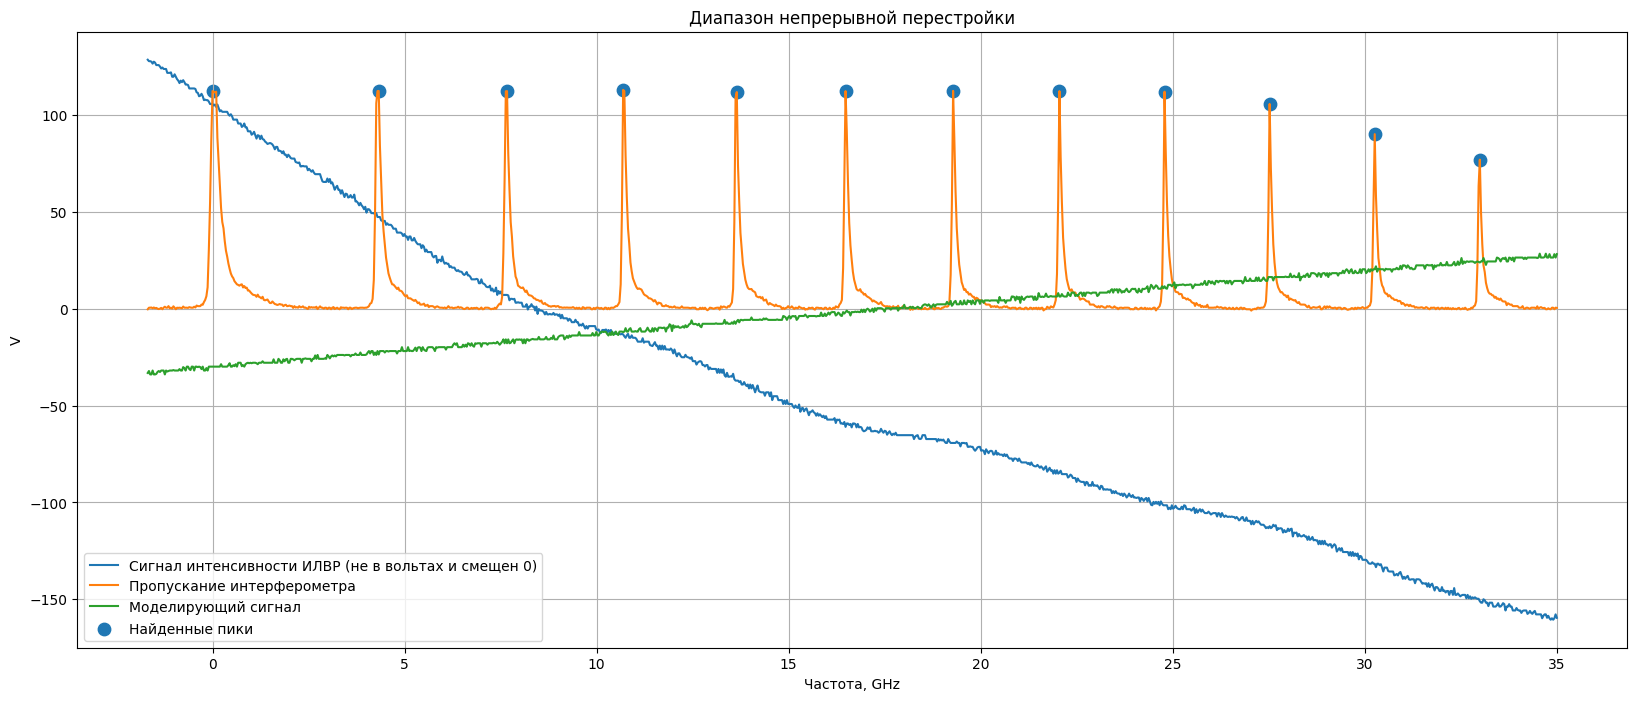


Диапазон непрерывной перестройки:
36.691 GHz


In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.signal import find_peaks


# ============================================================
#                     ЗАГРУЗКА ДАННЫХ
# ============================================================

data_5 = pd.read_csv("scope_5.csv")


# ============================================================
#                 ПАРАМЕТРЫ ОБЛАСТИ
# ============================================================

T_MIN = -0.008
T_MAX = 0.007

PEAK_DISTANCE_GHZ = 3


# ============================================================
#               ИСХОДНЫЙ ГРАФИК + ОБЛАСТЬ
# ============================================================

plt.figure(figsize=(20, 8))

plt.plot(
    data_5["T"],
    50 * data_5["V1"],
    label="Сигнал интенсивности ИЛВР (не в вольтах и смещен 0)"
)

plt.plot(
    data_5["T"],
    data_5["V2"],
    label="Пропускание интерферометра"
)

plt.plot(
    data_5["T"],
    data_5["V3"],
    label="Моделирующий сигнал"
)

# диапазон непрерывной перестройки
plt.axvspan(
    T_MIN,
    T_MAX,
    alpha=0.25,
    label="Диапазон непрерывной перестройки"
)

plt.xlabel("T, c")
plt.ylabel("V")

plt.grid()
plt.legend()

plt.savefig("gorbachev_1.png", dpi=100, bbox_inches='tight')
plt.show()


# ============================================================
#               ВЫДЕЛЯЕМ ОБЛАСТЬ
# ============================================================

mask = (
    (data_5["T"] >= T_MIN)
    &
    (data_5["T"] <= T_MAX)
)

T_region = data_5["T"][mask].values
V_region = data_5["V2"][mask].values


# ============================================================
#                   ПОИСК ПИКОВ
# ============================================================

peaks, props = find_peaks(
    V_region,
    prominence=20,
    distance=20
)

peak_times = T_region[peaks]

print(f"Количество пиков: {len(peaks)}")


# ============================================================
#           КАЛИБРОВКА ВРЕМЯ -> ЧАСТОТА
# ============================================================

peak_distances = np.diff(peak_times)

mean_peak_distance_time = np.mean(peak_distances)

GHz_per_second = (
    PEAK_DISTANCE_GHZ
    /
    mean_peak_distance_time
)

print(f"\nКалибровка:")
print(f"{GHz_per_second:.3e} GHz / s")


# ============================================================
#             ПЕРЕВОД ОСИ X В ЧАСТОТУ
# ============================================================

# ноль частоты ставим в первый пик

f_axis = (
    T_region - peak_times[0]
) * GHz_per_second


# ============================================================
#                 ГРАФИК В ЧАСТОТЕ
# ============================================================

plt.figure(figsize=(20, 8))

plt.plot(
    f_axis,
    50 * data_5["V1"][mask].values,
    label="Сигнал интенсивности ИЛВР (не в вольтах и смещен 0)"
)

plt.plot(
    f_axis,
    V_region,
    label="Пропускание интерферометра"
)

plt.plot(
    f_axis,
    data_5["V3"][mask].values,
    label="Моделирующий сигнал"
)

# пики
plt.scatter(
    (peak_times - peak_times[0]) * GHz_per_second,
    V_region[peaks],
    s=80,
    label="Найденные пики"
)

plt.xlabel("Частота, GHz")
plt.ylabel("V")

plt.title("Диапазон непрерывной перестройки")

plt.grid()
plt.legend()
plt.savefig("gorbachev_2.png", dpi=100, bbox_inches='tight')
plt.show()


# ============================================================
#             ОБЩИЙ ДИАПАЗОН ПЕРЕСТРОЙКИ
# ============================================================

total_frequency_span = (
    f_axis.max() - f_axis.min()
)

print(
    f"\nДиапазон непрерывной перестройки:"
)
print(
    f"{total_frequency_span:.3f} GHz"

)